---
title: "Tutorial 4: Linking Brain to Phenotypes (Part 1: Comparative Statistics)"
authors:
  - name: Sapolnach Prompiengchai
    affiliations:
      - University of Oxford
  - name: Aarushi Vardhan
    affiliations:
      - University of Toronto / University of Cambridge
---

# Overview

LEMON is well suited for studying brain–phenotype relationships because it combines resting-state fMRI with a rich collection of information about each participant. Besides brain imaging data, it includes younger and older adults, cognitive test scores, personality and emotion questionnaires, clinical assessments, and demographic information such as age, sex, education level, handedness, and smoking status. This allows researchers to investigate how differences in brain connectivity relate to many aspects of cognition, behaviour, and mental health.

The field has shown that resting-state functional connectivity can be used in two ways: to examine how brain measures are related to a phenotype, and to test whether those brain measures can help predict a phenotype in new people. In other words, connectivity patterns can be studied as correlates of age, cognition, behaviour, or clinical symptoms, and also as features that contain useful information about these outcomes.

However, more work is still needed because many findings in this area need to be replicated in newer datasets and in different populations. Results can also change depending on sample size, age range, preprocessing choices, and which phenotype is being studied. This is especially relevant for LEMON, since it offers a well-characterized healthy sample spanning young and older adults, together with a broad range of cognitive, emotional, personality, and clinical measures. This makes it well suited not only for evaluating whether previously reported brain–phenotype relationships generalize to an independent dataset, but also for identifying novel relationships. Because cognition, behaviour, personality, and mental health are multidimensional and often interrelated, comprehensive datasets such as LEMON provide an opportunity to explore how these complex phenotypes are reflected in patterns of brain connectivity.

# Tutorial: Studying Intrinsic Brain Organization in Healthy Aging

Aging concerns us all! What happens to our brain as we age? Do these changes in our aging brain also affect cognitive performance?

We know that healthy aging is accompanied by gradual changes in the brain's intrinsic functional organization. Some functional networks become less internally connected with age, while interactions between different networks may increase. 

However, these changes are **heterogeneous**—they do not occur uniformly across individuals or across brain networks. Understanding these patterns is an active area of research because they may help explain age-related changes in cognition, behaviour, and brain function.

First, using this dataset, let's first try to establish whether there's any differences in resting-state functional connectivity or rsFC between younger and older adults. 

Therefore our research question is

> **Is there a significant difference in resting-state functional connectivity between younger and older adults?**

Although this is only one example, it introduces many of the fundamental concepts used when linking brain data to a phenotype—in our case, **age**. 

Throughout this tutorial, you will learn how to summarize and visualize functional connectivity, formulate statistical hypotheses, compare groups using appropriate statistical tests, check statistical assumptions, and interpret the results. Along the way, we will introduce key statistical concepts in a hands-on manner, including measures of central tendency, standard deviation, z-scores, data distributions, hypothesis testing, correlation, linear regression, bootstrapping, and data visualization. Finally, we will discuss how to interpret and communicate your findings in the context of the existing neuroscience literature.

# Part 1: Descriptive Statistics

## Our Usual Setup

With that said, let's start coding! As usual, let's run our usual steps of setting project paths, etc. Additionally, we'll now be using the metadata of each subject in "META_File_IDs_Age_Gender_Education_Drug_Smoke_SKID_LEMON.csv" which also contains age information. 

In [ ]:
# ============================================================
# 0) Imports and project paths
# ============================================================

from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, levene, ttest_ind
from statsmodels.stats.multitest import multipletests

# Option 1: use the current working directory if the notebook lives inside the project folder
# PROJECT_DIR = Path.cwd()

# Option 2: manually specify your project directory if needed
PROJECT_DIR = Path("/Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026")

RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fc_stack_path = RESULTS_DIR / "subject_fc_stack.npy"
subject_ids_path = RESULTS_DIR / "subject_ids.npy"
region_names_path = RESULTS_DIR / "region_names.npy"
mean_fc_path = RESULTS_DIR / "mean_fc.npy"

# Behavioural / metadata directory
BEHAV_DIR = Path("/Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/data/Behavioural_Data_MPILMBB_LEMON")
meta_path = BEHAV_DIR / "META_File_IDs_Age_Gender_Education_Drug_Smoke_SKID_LEMON.csv" # contains age information

# Optional output folders
# TABLES_DIR = RESULTS_DIR / "tables"
# FIGURES_DIR = RESULTS_DIR / "figures"
# TABLES_DIR.mkdir(parents=True, exist_ok=True)
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Loading FC and Behavioural data

Next, we load our FC data as usual. Additionally, let's preprocess our metadata. 

To make our lives easier, we can 
* rename columns
* make sure we use English spellings (e.g., ambidextrous) and remove spaces if there's any (e.g., for subject_id) using .strip()
* convert age values "20-25" or "60-65" etc into Young or Old. (See the publications' **Methods/Participants** section)
* keep relevant columns
* only keep the rows where subject_id matches those in the FC


In [4]:
# ============================================================
# 1) Load FC data + metadata
# ============================================================

fc_stack = np.load(fc_stack_path)  # shape: (n_subjects, n_nodes, n_nodes)
subject_ids = np.load(subject_ids_path, allow_pickle=True).astype(str)
region_names = np.load(region_names_path, allow_pickle=True).astype(str)

meta = pd.read_csv(meta_path)

# Renaming some columns
meta = meta.rename(columns={
    "ID": "subject_id",
    "Gender_ 1=female_2=male": "gender_code",
    "Age": "age_bin",
    "Handedness": "handedness",
    "Education": "education",
    "Smoking_num_(Non-smoker=1, Occasional Smoker=2, Smoker=3)": "smoking_num",
})

# Clean up strings a bit
meta["subject_id"] = meta["subject_id"].astype(str).str.strip()
meta["handedness"] = meta["handedness"].astype(str).str.strip().replace({
    "ambedextor": "ambidextrous",
    "ambedextor ": "ambidextrous",
})
meta["education"] = meta["education"].astype(str).str.strip().replace({
    "Gymansium": "Gymnasium",
})

# Age group: LEMON has young bins (< 40) and old bins (>= 55)
def label_age_group(age_bin):
    if pd.isna(age_bin):
        return np.nan
    low = int(str(age_bin).split("-")[0])
    return "Young" if low < 40 else "Old"

meta["age_group"] = meta["age_bin"].apply(label_age_group)

# Gender labels (keep numeric code too, in case you need it later)
meta["sex"] = meta["gender_code"].map({1: "Female", 2: "Male"})

# Keep only the relevant columns
meta_clean = meta[[
    "subject_id", "age_bin", "age_group", "sex", "handedness", "education",
    "smoking_num", "DRUG_0=negative_1=Positive", "Hamilton_Scale",
    "BSL23_sumscore", "AUDIT", "Relationship_Status"
]].copy()

# Merge metadata to FC subject order
analysis_meta = pd.DataFrame({"subject_id": subject_ids}).merge(meta_clean, on="subject_id", how="left")

analysis_meta

,subject_id,age_bin,age_group,sex,handedness,education,smoking_num,DRUG_0=negative_1=Positive,Hamilton_Scale,BSL23_sumscore,AUDIT,Relationship_Status
0,sub-010002,65-70,Old,Female,right,Realschule,3.0,0.0,0.0,NaN,2.0,No
1,sub-010003,20-25,Young,Female,right,Gymnasium,1.0,0.0,3.0,NaN,1.0,No
2,sub-010004,65-70,Old,Female,right,Realschule,1.0,0.0,2.0,NaN,1.0,Yes
3,sub-010005,25-30,Young,Male,right,Gymnasium,1.0,0.0,0.0,4.0,1.0,No
4,sub-010006,65-70,Old,Female,ambidextrous,Realschule,1.0,0.0,0.0,NaN,2.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
215,sub-010317,20-25,Young,Male,right,Gymnasium,1.0,0.0,1.0,0.0,7.0,no
216,sub-010318,20-25,Young,Male,right,Gymnasium,1.0,0.0,2.0,8.0,2.0,yes
217,sub-010319,20-25,Young,Male,left,Gymnasium,1.0,0.0,0.0,2.0,6.0,No
218,sub-010320,20-25,Young,Male,right,Gymnasium,1.0,NaN,NaN,NaN,NaN,NaN


## Quick Statistics Refresher

If you are already familiar with concepts such as the **mean**, **median**, **standard deviation**, and **z-scores**, feel free to skip ahead to the next section. Otherwise, here is a quick refresher on the basic statistical concepts that will be used throughout these tutorials.

### Mean

The **mean** is the average value. It is calculated by adding all the values together and dividing by the total number of values.

For example, the mean of **2, 4, 6, 8** is: (2+4+6+8)/4 = 5

### Median

The **median** is the middle value after the data have been arranged from smallest to largest.

For example:

- **1, 3, 5, 7, 9** → Median = **5**
- **1, 3, 5, 7** → Median = **4**, which is the average of the two middle values, or [3+5]/2

Unlike the mean, the median is less affected by very large or very small values (outliers).

### Standard Deviation (SD)

The **standard deviation (SD)** measures how spread out the values are around the mean.

- A **small SD** means most values are close to the mean.
- A **large SD** means the values are more spread out.

For example, the datasets below have the same mean but different amounts of variation:

- **4, 5, 5, 6** → small standard deviation
- **1, 3, 7, 9** → large standard deviation

### Video Recommendation (mean/SD)
The following videos in the following order may help solidify your understanding of mean and SD: 
1. Mode, Median, Mean, Range, and Standard Deviation: https://www.youtube.com/watch?v=mk8tOD0t8M0
2. Standard Deviation - Explained and Visualized: https://www.youtube.com/watch?v=MRqtXL2WX2M

### Data Distributions

Many statistical methods assume that data follow a **normal distribution** (also called a **Gaussian distribution**). A normal distribution is the familiar bell-shaped curve where:

- Most values are close to the mean.
- Values become less common as they move further away from the mean.
- The distribution is **symmetric**, meaning the left and right sides are roughly mirror images.

A **standard normal distribution** is simply a normal distribution that has been standardized to have:

- Mean = **0**
- Standard deviation = **1**

This makes it convenient to compare measurements collected on different scales.

Not all data are normally distributed. Some datasets are **skewed**, meaning one side of the distribution has a longer tail than the other. For example, income data are often **right-skewed**, where most people have moderate incomes but a small number have very high incomes.

Many statistical tests work best when the data are approximately normally distributed. Later in this tutorial, we will learn how to check this assumption before choosing an appropriate statistical test.

### Z-score

A **z-score** tells us how far a value is from the mean, measured in units of standard deviations.

For example:

- **z = 0** means the value is exactly equal to the mean.
- **z = +1** means the value is one standard deviation above the mean.
- **z = -2** means the value is two standard deviations below the mean.

Z-scores are commonly used to standardize measurements so that values measured on different scales can be compared more easily.

### Video Recommendation (distribution and z-scores)
The following videos in the following order may help solidify your understanding of normal distribution and z-score: 
1. Symmetry and Skewness: https://www.youtube.com/watch?v=pfujiA5Mk_U 
1. The Normal Distribution, Clearly Explained!!!: https://www.youtube.com/watch?v=rzFX5NWojp0
2. Z-Scores, Standardization, and the Standard Normal Distribution: https://www.youtube.com/watch?v=2tuBREK_mgE


## Preparing Functional Connectivity for Statistical Analysis

### Fisher z-transform the FC

Now that we have reviewed some basic statistical concepts, we are ready to prepare our FC data for analysis.

For this tutorial, our goal is to answer questions such as whether functional connectivity measures are different between younger and older adults.

Many of the statistical methods used to answer these questions (such as *t*-tests, correlation, and linear regression) work best when the data are approximately normally distributed. However, FC values are Pearson correlation coefficients, which are naturally bounded between **-1 and +1** and therefore are not normally distributed, especially when the correlations are large.

To address this, it is common practice to apply a **Fisher z-transform** to the FC values before statistical analysis. This transformation converts correlation coefficients onto a new scale where their distribution is closer to a normal distribution, making subsequent statistical tests more appropriate.

In [5]:
# ============================================================
# 2) Fisher z-transform the FC
# ============================================================

def fisher_z_transform(fc):
    """Fisher z-transform a correlation matrix."""
    fc = np.asarray(fc, dtype=float)
    fc = np.clip(fc, -0.999999, 0.999999)  # since arctanh(1 or -1) gives infinity, we clip the values at +- 0.99999 instead.
    z = np.arctanh(fc)                     # fisher z-transform using arctanh
    np.fill_diagonal(z, np.nan)            # Remove self-connections by replacing the diagonal with NaN.
    return z

# for each fc in fc_stack, do fisher_z_transform
fc_stack_z = np.array([fisher_z_transform(fc) for fc in fc_stack])

fc_stack_z.shape

(220, 100, 100)

### Identifying Resting-State Networks (RSNs)

Each Schaefer atlas region has a label indicating which **resting-state network (RSN)** it belongs to (e.g., *Visual*, *DMN*, *FPN*). Before calculating within- and between-network connectivity, we first extract this network information from each region's label.

The code below performs three tasks:

1. **Renames** the original Schaefer network names to more familiar abbreviations (e.g., `Default` → `DMN`, `Cont` → `FPN`).
2. **Assigns** every brain region to its corresponding resting-state network.
3. **Creates a lookup table** containing the indices of all brain regions belonging to each network. This makes it easy to later calculate measures such as mean **within-network** and **between-network** functional connectivity.

In [6]:
# ============================================================
# 3) Define RSC/network labels from region names
# ============================================================

# Map Schaefer network names to more familiar abbreviations
NETWORK_NAME_MAP = {
    "Vis": "Visual",
    "SomMot": "SMN",          # Somatomotor Network
    "DorsAttn": "DAN",        # Dorsal Attention Network
    "SalVentAttn": "VAN",     # Ventral Attention (Salience) Network
    "Limbic": "Limbic",
    "Cont": "FPN",            # Frontoparietal Network
    "Default": "DMN",         # Default Mode Network
}

# Assumes format 7Networks_LH_Vis_1
def parse_network_name(label):
    """Extract and rename the functional network from a Schaefer atlas label."""
    parts = str(label).split("_")

    if len(parts) >= 4:
        schaefer_name = parts[2]                    # e.g. Vis, SomMot, DorsAttn
        return NETWORK_NAME_MAP.get(schaefer_name, schaefer_name)

    return "Unknown"

# Network label for each brain region
network_labels = np.array([parse_network_name(r) for r in region_names])

# Unique networks (preserve original order)
networks = list(dict.fromkeys(network_labels))

# Dictionary mapping each network to the indices of its regions
net_to_idx = {
    net: np.where(network_labels == net)[0]
    for net in networks
}

# Print seven unique network names
networks

[np.str_('Visual'),
 np.str_('SMN'),
 np.str_('DAN'),
 np.str_('VAN'),
 np.str_('Limbic'),
 np.str_('FPN'),
 np.str_('DMN')]

## Between- and Within-Network FC

So far, each subject has a **full functional connectivity (FC) matrix**, containing the connectivity between every pair of brain regions. For a 100-region atlas, this means there are **4,950 unique connections**. While this provides a detailed description of the brain, it is often difficult to interpret or statistically compare thousands of connections individually.

Instead, we can summarize the FC matrix into a smaller number of biologically meaningful features.

For each subject, we can calculate:

- **Overall within-network FC**: the average connectivity between brain regions that belong to the **same resting-state network (RSN)**. For example, we average all connections between regions within the **Default Mode Network (DMN)**, all connections within the **Visual Network**, all connections within the **Frontoparietal Network (FPN)**, and so on, before combining them into one overall within-network value.

- **Overall between-network FC**: the average connectivity between brain regions belonging to **different resting-state networks**. For example, this includes connections between the DMN and FPN, Visual and Somatomotor Network (SMN), DMN and Visual, and every other network pair.

These two measures provide a **global summary** of how strongly brain regions communicate **within** functional systems versus **between** functional systems.

We also calculate more detailed summaries:

- **Within each network**: the average connectivity between regions belonging to a single network. For example:
  - Mean connectivity **within the DMN**
  - Mean connectivity **within the Visual Network**
  - Mean connectivity **within the FPN**

- **Between each pair of networks**: the average connectivity between two specific networks. For example:
  - Mean connectivity **between the DMN and FPN**
  - Mean connectivity **between the Visual Network and SMN**
  - Mean connectivity **between the DMN and DAN**

These network-level summaries greatly reduce the complexity of the original FC matrix while retaining information about how different functional systems are organized. They are also much easier to compare between groups (e.g., younger vs. older adults) or relate to behavioural and clinical measures.

Finally, we compute these summaries using both the **original FC values** and the **Fisher z-transformed FC values**, allowing us to compare results obtained on each scale.

## Calculating Network-Network FC

The goal of this code is to turn each subject's full functional connectivity (FC) matrix into a few simple summary numbers. Instead of looking at thousands of connections one by one, we calculate the average connectivity:

- within the same resting-state network
- between different resting-state networks

We do this for each subject, and we do it twice: once for the original FC values and once for the Fisher z-transformed FC values.

This gives us a smaller table that is much easier to analyze later when comparing younger and older adults.

We will be using called function to make the code more readable and concise. 

### Why do we use functions?

Functions are useful because they let us package one repeated task into a reusable block of code.

Think of a function like a small machine:
- you give it an input
- it does one specific job
- it gives you an output

This is better than rewriting the same code many times, because it makes the notebook easier to read, easier to debug, and easier to reuse.

Specifically, we want input a subject's FC matrice to our the function so that the function can return us one of the following values:
- Overall within-network FC or between-network FC
- Average functional connectivity between one specific pair of networks (e.g., DMN-FPN connectivity)

In this case, we will create two functions:

- `get_overall_fc(...)`  
  This calculates the average FC for either:
  - connections within the same network, or
  - connections between different networks

- `get_network_pair_fc(...)`  
  This calculates the average FC between one specific pair of networks, such as DMN and FPN


In [19]:
# ============================================================
# Helper functions
# ============================================================

def get_overall_fc(mat, network_labels, kind="within"):
    """
    Calculate the mean functional connectivity (FC) for one subject.

    Parameters
    ----------
    mat : 2D numpy array
        Functional connectivity matrix for one subject.

    network_labels : array-like
        Resting-state network label for each brain region.
        Example: ["DMN", "DMN", "Visual", "Visual", ...]

    kind : str, default="within"
        Which connections to average:
        - "within"  : connections between regions in the same network
        - "between" : connections between regions in different networks

    Returns
    -------
    float
        Mean within-network or between-network FC for this subject.
    """

    # Ensure the input is a NumPy array
    mat = np.asarray(mat, dtype=float)

    # Create a mask for the upper triangle of the FC matrix.
    # Since FC matrices are symmetric, this prevents counting
    # every connection twice.
    upper_mask = np.triu(np.ones(mat.shape, dtype=bool), k=1)

    # Create a True/False matrix indicating whether every pair
    # of brain regions belongs to the same resting-state network.
    same_network = network_labels[:, None] == network_labels[None, :]

    # Select either within-network or between-network connections
    if kind == "within":
        mask = same_network & upper_mask

    elif kind == "between":
        mask = (~same_network) & upper_mask

    else:
        raise ValueError("kind must be either 'within' or 'between'")

    # Calculate the average FC of the selected connections
    return np.nanmean(mat[mask])


def get_network_pair_fc(mat, net_to_idx, net_a, net_b):
    """
    Calculate the mean FC between two specific resting-state networks
    for one subject.

    Parameters
    ----------
    mat : 2D numpy array
        Functional connectivity matrix for one subject.

    net_to_idx : dict
        Dictionary mapping each network name to the indices of its regions.
        Example:
            {
                "DMN": [12, 13, 14, ...],
                "FPN": [45, 46, 47, ...]
            }

    net_a : str
        Name of the first network.

    net_b : str
        Name of the second network.

    Returns
    -------
    float
        Mean FC between the two specified networks.
    """

    # Ensure the input is a NumPy array
    mat = np.asarray(mat, dtype=float)

    # Find the brain regions belonging to each network
    idx_a = net_to_idx[net_a]
    idx_b = net_to_idx[net_b]

    # Extract all connections between the two networks
    network_pair = mat[np.ix_(idx_a, idx_b)]

    # Return the average FC between the two networks
    return np.nanmean(network_pair)

Next, we will use our function to calculate network connectivity for all subjects. 

The logic is:

1. Take one subject's FC matrix.
2. Decide whether we want within-network or between-network connectivity.
3. Select the relevant connections.
4. Compute the mean.
5. Repeat for all subjects.
6. Put the results into a table.

Specifically, the loop goes through the subjects one by one.

For each subject, it takes:
- the raw FC matrix from `fc_stack`
- the Fisher z-transformed FC matrix from `fc_stack_z`

Then it calls the function four times:
- raw within-network FC
- raw between-network FC
- z-transformed within-network FC
- z-transformed between-network FC

Each answer is added to a list that we initilise (e.g., `raw_within_all`, `raw_between_all`). At the end, those lists are combined into a dataframe called `summary_df`.

So the loop is just a way of applying the same calculation to every subject in the dataset.

In [ ]:
# ============================================================
# Calculate overall within-network and between-network FC
# for every subject, for raw FC and Fisher z FC
# ============================================================

# Initialise lists
raw_within_all = []
raw_between_all = []
z_within_all = []
z_between_all = []

# Loop
for raw_fc, z_fc in zip(fc_stack, fc_stack_z):
    raw_within_all.append(get_overall_fc(raw_fc, network_labels, kind="within"))
    raw_between_all.append(get_overall_fc(raw_fc, network_labels, kind="between"))
    
    z_within_all.append(get_overall_fc(z_fc, network_labels, kind="within"))
    z_between_all.append(get_overall_fc(z_fc, network_labels, kind="between"))

# Put results in a simple table
summary_df = pd.DataFrame({
    "subject_id": subject_ids,
    "raw_within_all": raw_within_all,
    "raw_between_all": raw_between_all,
    "z_within_all": z_within_all,
    "z_between_all": z_between_all,
})

# Add group (age) labels if you already merged metadata
summary_df = summary_df.merge(analysis_meta[["subject_id", "age_group"]], on="subject_id", how="left")

summary_df

,subject_id,raw_within_all,raw_between_all,z_within_all,z_between_all,age_group
0,sub-010002,0.430220,0.134788,0.512496,0.146496,Old
1,sub-010003,0.522442,0.267634,0.631099,0.292061,Young
2,sub-010004,0.504333,0.260840,0.644192,0.291162,Old
3,sub-010005,0.656088,0.452117,0.865692,0.520825,Young
4,sub-010006,0.610286,0.366996,0.768811,0.415498,Old
...,...,...,...,...,...,...
215,sub-010317,0.483092,0.225788,0.581619,0.241099,Young
216,sub-010318,0.526544,0.297969,0.645913,0.328726,Young
217,sub-010319,0.487470,0.261582,0.608796,0.295634,Young
218,sub-010320,0.620213,0.379587,0.819731,0.433900,Young


### Visualizing the group averages

Now, let's **visualize the data**. Plots provide a quick overview of the data. 

Here, we compare the **average functional connectivity (FC)** between younger and older adults for four measures:

- Overall **within-network** FC (raw correlations)
- Overall **between-network** FC (raw correlations)
- Overall **within-network** FC (Fisher z-transformed)
- Overall **between-network** FC (Fisher z-transformed)

Each bar represents the **group mean**, while the error bars represent the **standard error of the mean (SEM)**, giving an indication of the uncertainty around each group's average. At this stage, these plots are purely descriptive—they allow us to visually compare the groups before formally testing whether any observed differences are statistically significant.

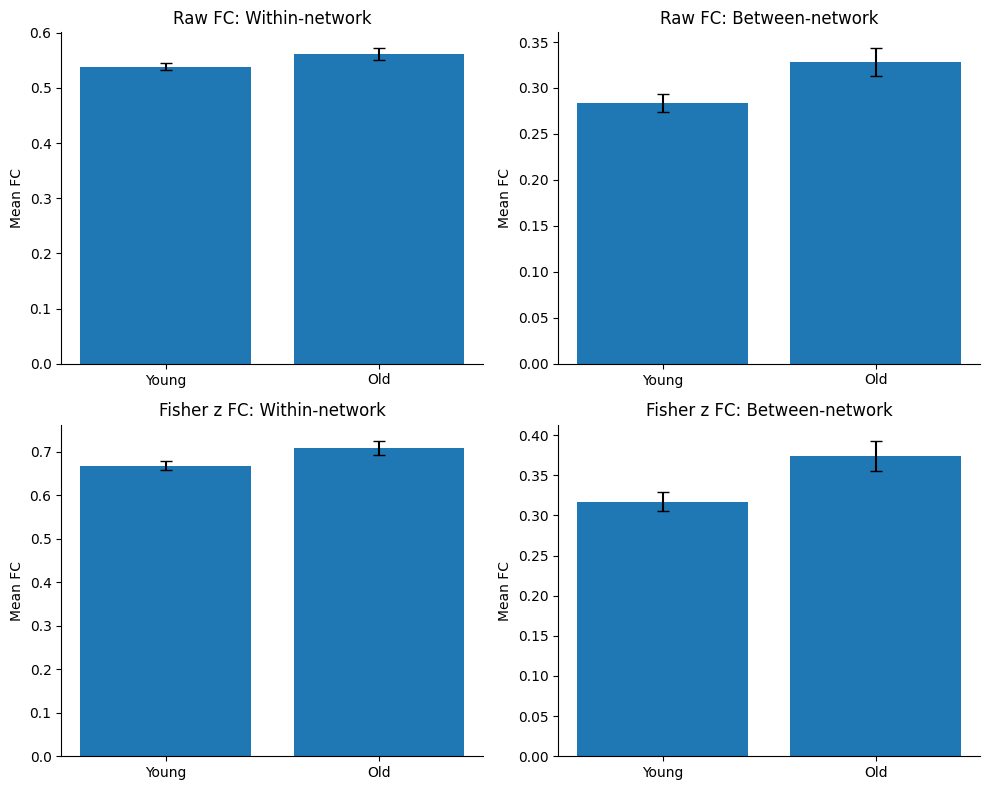

In [23]:
# ============================================================
# Plot overall within- and between-network FC
# for younger and older adults
# ============================================================

def plot_group_bar(df, value_col, title, ax):
    """
    Plot the mean FC for younger and older adults.

    Parameters
    ----------
    df : pandas DataFrame
        Table containing the summary FC values.

    value_col : str
        Name of the column to plot.

    title : str
        Title shown above the plot.

    ax : matplotlib axis
        Axis on which the bar plot will be drawn.
    """

    # --------------------------------------------------------
    # Separate the data into the two age groups
    # --------------------------------------------------------
    young = df.loc[df["age_group"] == "Young", value_col].dropna()
    old = df.loc[df["age_group"] == "Old", value_col].dropna()

    # --------------------------------------------------------
    # Calculate the group means
    # --------------------------------------------------------
    means = [
        young.mean(),
        old.mean()
    ]

    # --------------------------------------------------------
    # Calculate the standard error of the mean (SEM)
    # SEM = SD / sqrt(sample size)
    # This is what will be shown as the error bars.
    # --------------------------------------------------------
    sems = [
        young.std(ddof=1) / np.sqrt(len(young)),
        old.std(ddof=1) / np.sqrt(len(old))
    ]

    # --------------------------------------------------------
    # Draw the bar plot
    # --------------------------------------------------------
    ax.bar(
        ["Young", "Old"],     # x-axis labels
        means,                # bar heights
        yerr=sems,            # error bars
        capsize=4             # width of the error bar caps
    )

    # Add labels and title
    ax.set_title(title)
    ax.set_ylabel("Mean FC")

    # Remove unnecessary borders for a cleaner figure
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# Create a 2 × 2 figure
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot each FC summary
plot_group_bar(summary_df, "raw_within_all", "Raw FC: Within-network", axes[0, 0])
plot_group_bar(summary_df, "raw_between_all", "Raw FC: Between-network", axes[0, 1])
plot_group_bar(summary_df, "z_within_all", "Fisher z FC: Within-network", axes[1, 0])
plot_group_bar(summary_df, "z_between_all", "Fisher z FC: Between-network", axes[1, 1])

# Automatically adjust spacing between subplots
plt.tight_layout()

# Display the figure
plt.show()

### Interpreting the Plots: Sample vs Population

These plots provide an initial, **descriptive** comparison of the two age groups. Visually, the results appear very similar whether we use the **raw FC values** or the **Fisher z-transformed FC values**, suggesting that the Fisher z-transform changes the numerical scale but not the overall pattern of the data.

From the plots, we observe that older adults appear to have **higher average within-network FC** and **higher average between-network FC** than younger adults. While these differences are visible, it is important to remember that the plots only show the **sample means** and their **standard errors**. They do **not** tell us whether the observed differences reflect genuine differences in the wider population.

This naturally leads to an important question:

> **Are these differences larger than we would expect simply due to random sampling variation?**

To understand why this matters, consider what our data represent. We did **not** scan every younger and older adult in the world. Instead, we collected data from a relatively small group of participants, known as a **sample**. Our goal is to use this sample to learn something about the much larger **population** of younger and older adults.

Now imagine we repeated the study. We recruit a different group of 200 healthy participants and calculate the same averages again. Even if there were **no true difference** between younger and older adults in the population, the group means would almost certainly not be identical. This is because every sample is slightly different, and **samples naturally vary due to chance**. This is known as **sampling variation**.

Therefore, simply observing that one bar is taller than another is **not enough** to conclude that a real difference exists between the two age groups.

To answer this question, we use **statistical hypothesis tests**. These tests compare the difference we observed with the amount of difference we would expect from random sampling variation alone. If the observed difference is much larger than we would typically expect by chance, we say the result is **statistically significant**. In other words, the evidence suggests that the difference we observed is likely to reflect a genuine difference in the population rather than random variation in our particular sample.

In the next section, we will learn how to formally test whether the differences observed in these plots are statistically significant using a **two-sample t-test**.

# Part 2: Comparative Statistics

In the previous section, we summarized and visualized the functional connectivity (FC) data. We observed that older adults appeared to have higher average within-network and between-network FC than younger adults.

However, visual inspection alone is **not enough** to conclude that these differences are real.

As discussed previously, our data come from only a **sample** of the wider population. If we repeated the study with a different group of participants, the group averages would almost certainly change slightly due to **sampling variation**.

The goal of statistical testing is therefore to answer a simple question:

> **Are the differences we observed likely to reflect genuine differences in the population, or could they simply be due to random sampling variation?**

[Note: for those familiar with statistical tests such as t-tests and ANOVA, feel free to skip directly to the code.]

## Hypothesis Testing

Statistical hypothesis testing provides a formal way of answering this question.

Every hypothesis test begins with two competing hypotheses:

- **Null hypothesis (H₀):** There is **no difference** between the groups.
- **Alternative hypothesis (H₁):** There **is** a difference between the groups.

In our tutorial, the research question is:

> **Is resting-state functional connectivity different between younger and older adults?**

This translates into the following hypotheses:

- **H₀:** Younger and older adults have the same average functional connectivity.
- **H₁:** Younger and older adults have different average functional connectivity.

The statistical test uses the observed data to evaluate which of these hypotheses is more consistent with the evidence.

## Choosing the Correct Statistical Test

There is no single statistical test that is appropriate for every research question. The choice of test depends on several factors, including:

- What type of variable are we studying?
- How many groups are being compared?
- Whether the observations come from **different participants** (independent) or **the same participants measured multiple times** (paired).
- Whether the assumptions of the statistical test are reasonably satisfied.

For example:

| Example research question | Data structure | Example test |
|---------------------------|----------------|--------------|
| **Is average functional connectivity different between younger and older adults?** | Two independent groups | Independent two-sample *t*-test |
| **Does average functional connectivity change before and after an intervention in the same participants?** | Two paired (repeated) measurements | Paired *t*-test |
| **Is average functional connectivity different among younger, middle-aged, and older adults?** | Three or more independent groups | ANOVA |
| **Is functional connectivity associated with age measured in years?** | Two continuous variables | Correlation or linear regression |

In this tutorial, our phenotype (**age group**) is **categorical**, consisting of two **independent** groups: younger adults and older adults. Here, *independent* simply means that each participant belongs to **only one group**. No participant appears in both groups, and each person's measurement is unrelated to the measurements of other participants.

Therefore, our first statistical analysis will compare the average functional connectivity between these two groups using an **independent two-sample *t*-test**.

## Why do statistical tests have assumptions?

Most statistical tests are based on mathematical models. These models describe what we would expect to observe if the null hypothesis were true.

For these mathematical models to produce reliable results, certain assumptions should be approximately satisfied. If these assumptions are seriously violated, the conclusions of the statistical test may become less reliable.

Fortunately, many statistical tests are fairly robust to small violations of their assumptions, especially when sample sizes are reasonably large. Nevertheless, it is considered good scientific practice to check the assumptions before interpreting the results.

In this tutorial, we will learn how to check these assumptions before performing our statistical tests.

## The Independent Two-Sample *t*-Test

The **independent two-sample *t*-test** is one of the most commonly used statistical tests. It is designed to answer a simple question:

> **Are the average values of a variable different between two independent groups?**

In our case, the variable is **mean functional connectivity**, and the two independent groups are **younger adults** and **older adults**.

Intuitively, the *t*-test compares the difference between the two group means with the amount of variation within each group.

For example, suppose we measured the average within-network FC for every participant:

| Group | Mean FC |
|--------|--------:|
| Younger adults | 0.28 |
| Older adults | 0.34 |

The group means differ by **0.06**. But is this a meaningful difference?

The answer depends on **how much variability there is within each group**.

- If almost everyone in each group has FC values close to their group mean, then a difference of **0.06** may be substantial.
- However, if FC values vary widely from person to person, then a difference of **0.06** could simply reflect natural variation within the sample.

The *t*-test combines these two pieces of information—the **difference between the group means** and the **variation within each group**—into a single number called the ***t*-statistic**.

A **larger absolute *t*-value** indicates that the difference between the group means is large relative to the variability within the groups, providing stronger evidence that the groups differ. A ***t*-value close to zero** suggests that the observed difference is small compared with the natural variation in the data.

Later, this *t*-statistic is converted into a **p-value**, which tells us how likely it would be to observe a difference this large if there were actually no true difference between the groups.

## Understanding t- and p-values

Recall our research question:

> **Is mean functional connectivity different between younger and older adults?**

Our hypotheses were:

- **Null hypothesis (H₀):** Younger and older adults have the same average functional connectivity.
- **Alternative hypothesis (H₁):** Younger and older adults have different average functional connectivity.

Suppose we perform an independent two-sample *t*-test. We would normally obtain two values, t- and p-value, such as

> *t* = 2.73, *p* = 0.007

A useful way to think about it is:

- A ***t*-statistic** tells us **how large the observed difference is relative to the natural variation in the data.**
- A **p-value** converts that information into a **probability**, telling us how surprising our result would be if the null hypothesis were true.

Generally, the larger the absolute *t*-statistic, the smaller the p-value, and therefore the stronger the evidence against the null hypothesis.

How should we interpret this?

The ***t*-statistic (2.73)** tells us that the observed difference between the two group means is relatively large compared with the natural variability within the groups. In other words, the difference between younger and older adults is larger than we would expect if the group means differed only because of random sampling variation.

The **p-value (0.007)** tells us how likely it would be to observe a *t*-statistic at least this large **if the null hypothesis were true**—that is, if there were actually **no true difference** in mean functional connectivity between younger and older adults in the population.

Since **0.007** is quite small, this suggests that our observed difference would be unlikely to occur purely by chance. Therefore, we **reject the null hypothesis** and conclude that the data provide evidence of a difference in mean functional connectivity between younger and older adults.

A typical way to report this result in a paper would be:

> Mean within-network functional connectivity was significantly higher in older adults than younger adults (Welch's t = 2.73, p = 0.007).

Notice that we **do not** conclude that aging *causes* the difference. Instead, we conclude thattwo age groups significantly differ in their average functional connectivity.

## Assumptions for t-tests

Now that we want to do an independent two-sample t-test, let's check whether its underlying assumptions are reasonably satisfied.

For our tutorial, let's specifically choose **Welch's *t*-test** that we will use is relatively robust and makes fewer assumptions than the classical Student's *t*-test. Nevertheless, it is still useful to understand the assumptions and examine our data before interpreting the results.

For our analysis, we will consider the following assumptions:

### 1. Independent observations

Each participant should contribute **one independent measurement**, and one participant's data should not influence another participant's data.

In our study, this assumption is satisfied because each participant belongs to either the younger or older group and was scanned only once.

### 2. Approximately normal data

The *t*-test assumes that the variable being compared (e.g., mean within-network FC) is approximately normally distributed **within each group**.

For example, the distribution of mean within-network FC among younger adults should be roughly bell-shaped, and the same should hold for older adults.

To assess this, we will:

- visually inspect the data (e.g., histograms), and
- perform a **Shapiro–Wilk test**.

Small departures from normality are usually not a major concern, especially when sample sizes are moderate or large.

### 3. Similar variances (not required for Welch's *t*-test)

The classical Student's *t*-test assumes that the two groups have **equal variances**, meaning that the amount of variability is similar in each group.

Welch's *t*-test was specifically developed to relax this assumption, making it appropriate even when the two groups have different variances or different sample sizes.

Although this assumption is **not required** for Welch's *t*-test, we will still examine the group variances using **Levene's test**. This helps us better understand our data and illustrates why Welch's *t*-test is generally preferred in practice.

In the following sections, we will learn how to check each of these assumptions before performing the two-sample *t*-test.

## Interpreting Assumption Tests

Before we compare younger and older adults, we first check whether the data are suitable for the statistical test we plan to use.

### Normality

To assess whether the data are approximately normally distributed, we will use:

- **Histograms** to visually inspect the shape of the data.
- The **Shapiro–Wilk test** to formally test for normality.

For the **Shapiro–Wilk test**:

- **Null hypothesis (H₀):** The data are normally distributed.
- **Alternative hypothesis (H₁):** The data are not normally distributed.

Therefore:

- **p ≥ 0.05:** We do **not** have sufficient evidence to conclude that the data are non-normal. The normality assumption is considered **reasonable**.
- **p < 0.05:** The data significantly deviates from a normal distribution

Keep in mind that the Shapiro–Wilk test can be sensitive to sample size. With large samples, even small departures from normality may produce a significant result. Therefore, it is good practice to interpret the test **together with the histogram**, rather than relying on the p-value alone.


==================== raw_within_all ====================
Young group (n=151):
  Shapiro-Wilk W = 0.9846, p = 0.09168
Old group (n=68):
  Shapiro-Wilk W = 0.9821, p = 0.4378


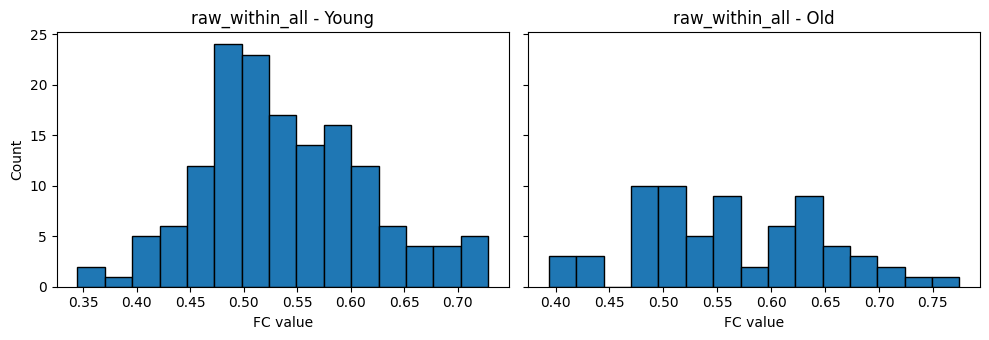


==================== raw_between_all ====================
Young group (n=151):
  Shapiro-Wilk W = 0.9809, p = 0.03431
Old group (n=68):
  Shapiro-Wilk W = 0.9612, p = 0.03285


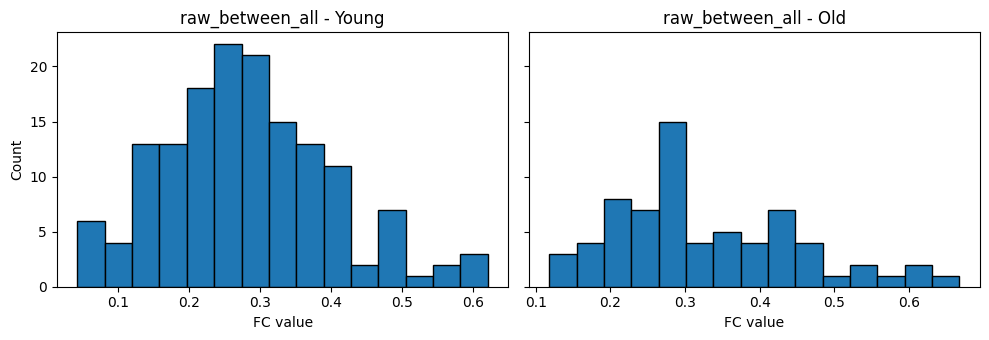


==================== z_within_all ====================
Young group (n=151):
  Shapiro-Wilk W = 0.9662, p = 0.0009041
Old group (n=68):
  Shapiro-Wilk W = 0.9765, p = 0.2274


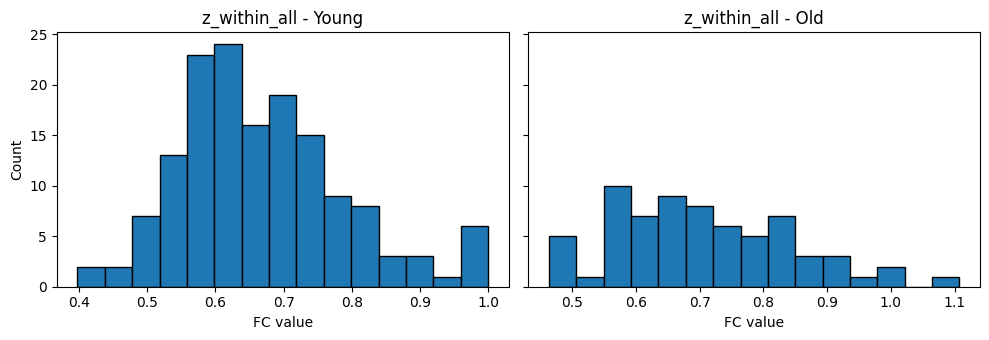


==================== z_between_all ====================
Young group (n=151):
  Shapiro-Wilk W = 0.9637, p = 0.000522
Old group (n=68):
  Shapiro-Wilk W = 0.9413, p = 0.003105


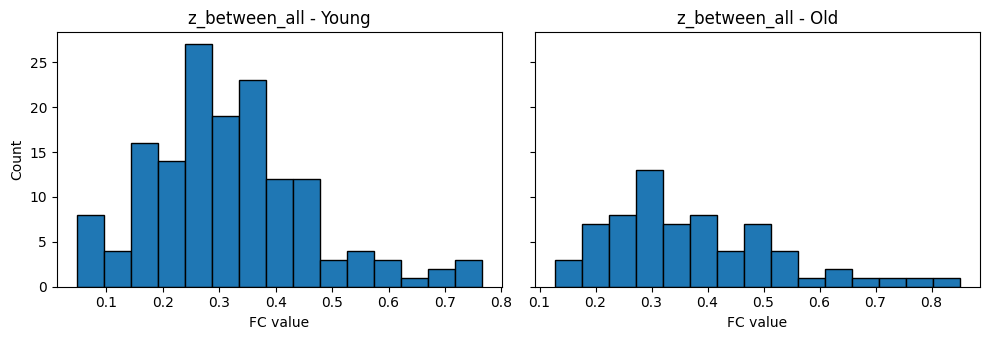

In [27]:
# Columns to check
normality_cols = [
    "raw_within_all",
    "raw_between_all",
    "z_within_all",
    "z_between_all",
]

# Loop through each FC summary column
for col in normality_cols:
    print(f"\n==================== {col} ====================")

    # Split the data into younger and older groups
    young = summary_df.loc[summary_df["age_group"] == "Young", col].dropna()
    old = summary_df.loc[summary_df["age_group"] == "Old", col].dropna()

    # -----------------------------
    # Shapiro-Wilk test
    # -----------------------------
    # This tests whether each group's data deviate from normality.
    # Small p-value (< 0.05) suggests the distribution is not normal.
    shapiro_young = shapiro(young) if len(young) >= 3 else None
    shapiro_old = shapiro(old) if len(old) >= 3 else None

    print(f"Young group (n={len(young)}):")
    if shapiro_young is not None:
        print(f"  Shapiro-Wilk W = {shapiro_young.statistic:.4f}, p = {shapiro_young.pvalue:.4g}")
    else:
        print("  Not enough data for Shapiro-Wilk test")

    print(f"Old group (n={len(old)}):")
    if shapiro_old is not None:
        print(f"  Shapiro-Wilk W = {shapiro_old.statistic:.4f}, p = {shapiro_old.pvalue:.4g}")
    else:
        print("  Not enough data for Shapiro-Wilk test")

    # -----------------------------
    # Histogram plot
    # -----------------------------
    # Visual check of the distribution shape in each group.
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

    axes[0].hist(young, bins=15, edgecolor="black")
    axes[0].set_title(f"{col} - Young")
    axes[0].set_xlabel("FC value")
    axes[0].set_ylabel("Count")

    axes[1].hist(old, bins=15, edgecolor="black")
    axes[1].set_title(f"{col} - Old")
    axes[1].set_xlabel("FC value")

    plt.tight_layout()
    plt.show()

### Interpreting the Normality Results

Let's now interpret the histograms and the Shapiro–Wilk test together.

**Step 1: Visually inspect the histograms**

Before looking at the p-values, it is always useful to first ask:

> **Do the distributions look approximately bell-shaped and reasonably symmetric?**

Notice that the histograms are **not perfectly symmetric**, but they are also not extremely skewed.

One useful feature to look for is whether **most observations are concentrated around the middle of the distribution**, with fewer observations towards the extremes. This is one of the main characteristics of a normal distribution.

The y-axis of the histogram shows the **count**, which is simply the number of observations that fall within a particular range (called a **bin**).

For example, if one bar spans FC values between approximately **0.50 and 0.525** and has a height of **23**, this means that **23 participants** have FC values within that interval.

Overall, these histograms appear reasonably bell-shaped, although some show slight skewness (asymmetry). 

---

**Step 2: Interpret the Shapiro–Wilk test**

The Shapiro–Wilk test provides a formal statistical test of normality.

Recall its hypotheses:

- **Null hypothesis (H₀):** The data are normally distributed.
- **Alternative hypothesis (H₁):** The data are not normally distributed.

Therefore:

- **p ≥ 0.05:** We do not have sufficient evidence to conclude that the data are non-normal.
- **p < 0.05:** The data show evidence of departing from a normal distribution.

Let's interpret our results.

---

**For raw within-network FC,**

Young adults:

```text
W = 0.9846
p = 0.0917
```

Older adults:

```text
W = 0.9821
p = 0.4378
```

Both p-values are **greater than 0.05**, so we do **not** have sufficient evidence to conclude that either group's data deviate from normality.

This agrees well with what we observed in the histograms.

---

**For raw between-network FC**

Young adults:

```text
p = 0.0343
```

Older adults:

```text
p = 0.0329
```

Both p-values are now **less than 0.05**, suggesting that the distributions differ from a perfect normal distribution.

However, notice that the histograms still appear reasonably bell-shaped. This illustrates an important point:

> **Statistical tests and visual inspection should always be interpreted together.**

The Shapiro–Wilk test is quite sensitive, particularly when sample sizes are moderate or large. Even relatively small departures from a perfect normal distribution can produce a statistically significant result.

---

**For fisher z-transformed within-network FC**

Young adults:

```text
p = 0.0009
```

Older adults:

```text
p = 0.227
```

For the younger group, the p-value is **less than 0.05**, suggesting evidence against normality. The older group does not show evidence of departing from normality.

Interestingly, this means that **the Fisher z-transform did not make the within-network FC more normally distributed in this dataset**. In fact, for the younger group, the transformed values appear less consistent with the normality assumption than the original FC values.

This is a useful reminder that the Fisher z-transform is **not guaranteed** to make every summary measure perfectly normal. It is designed to improve the statistical properties of **correlation coefficients**, but after averaging correlations (such as computing mean within-network FC), the resulting distribution may not necessarily become more normal.

---

**For fisher z-transformed between-network FC**

Young adults:

```text
p = 0.0005
```

Older adults:

```text
p = 0.0031
```

Both p-values are less than **0.05**, suggesting evidence that these distributions depart from normality.

Again, this demonstrates that the Fisher z-transform did not improve the normality of these summary measures in this particular analysis.

---

**What should we do?**

At first glance, these results might seem concerning because several of the Shapiro–Wilk tests are statistically significant.

Fortunately, this does **not** necessarily mean that we cannot perform a *t*-test.

The independent *t*-test—is generally considered **robust** to moderate departures from normality, particularly when sample sizes are reasonably large. In our study, we have the FC for **151 younger adults** and **68 older adults**, which are relatively large sample sizes for a neuroimaging study.

Therefore, although some of the Shapiro–Wilk tests suggest that the distributions are not perfectly normal, the histograms do not indicate **severe** departures from normality. Combined with our moderate sample sizes and the robustness of Welch's *t*-test, these results suggest that it is reasonable to proceed with the planned statistical analysis.

This example also highlights an important lesson:

> **Assumption checks should be interpreted using both statistical tests and visual inspection, rather than relying on a single p-value alone.**

### Equal Variances

Next, to assess whether the younger and older groups have similar variability, we will use **Levene's test**.

For **Levene's test**:

- **Null hypothesis (H₀):** The two groups have equal variances.
- **Alternative hypothesis (H₁):** The two groups have different variances.

Therefore:

- **p ≥ 0.05:** We do **not** have sufficient evidence to conclude that the group variances differ.
- **p < 0.05:** There is evidence that the group variances are different.

In [28]:
# ============================================================
# Variance check: Levene's test
# For overall within-network and between-network FC
# ============================================================

from scipy.stats import levene

# Columns to check
variance_cols = [
    "raw_within_all",
    "raw_between_all",
    "z_within_all",
    "z_between_all",
]

for col in variance_cols:
    print(f"\n==================== {col} ====================")

    # Split into younger and older groups
    young = summary_df.loc[summary_df["age_group"] == "Young", col].dropna()
    old = summary_df.loc[summary_df["age_group"] == "Old", col].dropna()

    # Levene's test checks whether the groups have similar variance
    # center="median" makes the test a bit more robust
    lev = levene(young, old, center="median")

    print(f"Young group variance: {np.var(young, ddof=1):.6f}")
    print(f"Old group variance:   {np.var(old, ddof=1):.6f}")
    print(f"Levene's test: W = {lev.statistic:.4f}, p = {lev.pvalue:.4g}")


==================== raw_within_all ====================
Young group variance: 0.005938
Old group variance:   0.007387
Levene's test: W = 2.2247, p = 0.1373

==================== raw_between_all ====================
Young group variance: 0.014146
Old group variance:   0.015134
Levene's test: W = 0.1376, p = 0.711

==================== z_within_all ====================
Young group variance: 0.014647
Old group variance:   0.019065
Levene's test: W = 2.0140, p = 0.1573

==================== z_between_all ====================
Young group variance: 0.020288
Old group variance:   0.023909
Levene's test: W = 0.4828, p = 0.4879


For all four FC measures, the p-values are **greater than 0.05**:

| Measure | Levene's p-value | Interpretation |
|---------|-----------------:|----------------|
| Raw within-network FC | 0.137 | No evidence that the variances differ. |
| Raw between-network FC | 0.711 | No evidence that the variances differ. |
| Fisher z within-network FC | 0.157 | No evidence that the variances differ. |
| Fisher z between-network FC | 0.488 | No evidence that the variances differ. |

Although the younger and older groups do not have **exactly** the same variance (for example, the older group has a slightly larger variance for all four measures), these differences are relatively small and are **not statistically significant** according to Levene's test.

This means that the assumption of equal variances appears reasonable for these data.

### Summary: Assumption Checks

So, what do these results mean?

Overall, the assumption checks suggest that it is reasonable to proceed with a two-sample *t*-test. 

Although several of the Shapiro–Wilk tests indicated departures from perfect normality, both the histograms and our relatively large sample sizes (151 younger adults and 68 older adults) suggest that these departures are unlikely to substantially affect the results. In general, *t*-tests are considered **robust to moderate departures from normality**, particularly when sample sizes are reasonably large.

Furthermore, Levene's test found **no evidence of unequal variances** for any of the four summary FC measures. Based on these assumption checks, either the classical Student's *t*-test or Welch's *t*-test would be appropriate for the current analysis.

However, throughout the remainder of this tutorial we will analyse many additional brain measures, including individual network-level summaries and network-to-network connectivity. Because the younger and older groups contain **different numbers of participants**, the estimated **variances** for some of these measures may differ simply due to sampling variability. Rather than deciding on a different statistical test for each measure, we will consistently use **Welch's *t*-test**.

Welch's *t*-test does **not** assume that the two groups have equal variances. Instead, it adjusts the calculation of the test statistic and its degrees of freedom to account for possible differences in variance and unequal sample sizes. When the group variances are actually equal, Welch's *t*-test performs almost identically to the classical Student's *t*-test. When the variances differ, however, Welch's *t*-test generally provides more reliable results. For this reason, it has become the preferred default choice in many areas of biomedical and psychological research.

## Performing the Welch's Two-Sample *t*-Test

Having checked the assumptions, we can now perform the statistical test.

Recall our research question:

> **Is mean functional connectivity different between younger and older adults?**

To answer this, we will use **Welch's two-sample *t*-test**.

The output of the test contains three important quantities:

- **The *t*-statistic** measures how large the difference between the group means is relative to the variability within the groups. Larger absolute *t*-values provide stronger evidence that the groups differ.

- **The degrees of freedom (d.f.)** determine which theoretical *t*-distribution should be used when calculating the p-value. Unlike the classical Student's *t*-test, Welch's *t*-test estimates the degrees of freedom from both the sample sizes and the group variances. As a result, the degrees of freedom are often **not whole numbers**. Detailed understanding of d.f. is not required for this tutorial.

- **The p-value** quantifies how likely it would be to observe a difference at least as large as the one in our data if the null hypothesis were true. Conventionally, **p < 0.05** is considered statistically significant.

Let's do t-test using the **raw functional connectivity values**.

In [30]:
# ============================================================
# Welch's two-sample t-test
# Using the raw FC summaries
# ============================================================

from scipy.stats import ttest_ind

# Variables to test
test_columns = [
    "raw_within_all",
    "raw_between_all"
]

for col in test_columns:

    print(f"\n==================== {col} ====================")

    # Split data into younger and older adults
    young = summary_df.loc[
        summary_df["age_group"] == "Young",
        col
    ].dropna()

    old = summary_df.loc[
        summary_df["age_group"] == "Old",
        col
    ].dropna()

    # Welch's two-sample t-test
    # equal_var=False tells scipy to perform Welch's t-test
    result = ttest_ind(
        young,
        old,
        equal_var=False
    )

    # Print descriptive statistics
    print(f"Young: Mean = {young.mean():.4f}, SD = {young.std(ddof=1):.4f}, n = {len(young)}")
    print(f"Old:   Mean = {old.mean():.4f}, SD = {old.std(ddof=1):.4f}, n = {len(old)}")

    # Print test results
    print(f"t = {result.statistic:.3f}")
    print(f"d.f. = {result.df:.2f}")
    print(f"p = {result.pvalue:.5f}")


==================== raw_within_all ====================
Young: Mean = 0.5380, SD = 0.0771, n = 151
Old:   Mean = 0.5616, SD = 0.0859, n = 68
t = -1.945
d.f. = 117.42
p = 0.05420

==================== raw_between_all ====================
Young: Mean = 0.2837, SD = 0.1189, n = 151
Old:   Mean = 0.3285, SD = 0.1230, n = 68
t = -2.518
d.f. = 125.35
p = 0.01305


### Interpreting T-Test Results

When reporting a two-sample *t*-test, it is good practice to report:

- the group means,
- the standard deviations (SD),
- the *t*-statistic,
- the degrees of freedom (d.f.),
- and the p-value.

Our results were:

Overall within-network FC

| Group | Mean ± SD |
|------|-----------:|
| Younger adults | 0.538 ± 0.077 |
| Older adults | 0.562 ± 0.086 |

Welch's *t*-test:

```text
t = -1.945
d.f. = 117.42
p = 0.054
```

Although older adults had a slightly higher average within-network FC than younger adults, the **p-value is greater than 0.05**. Therefore, based on the conventional significance threshold, we **do not have sufficient evidence to reject the null hypothesis**. In other words, our data do not provide strong enough evidence that the two groups differ in overall within-network FC.

---

Overall between-network FC

| Group | Mean ± SD |
|------|-----------:|
| Younger adults | 0.284 ± 0.119 |
| Older adults | 0.329 ± 0.123 |

Welch's *t*-test:

```text
t = -2.518
d.f. = 125.35
p = 0.013
```

Here, the **p-value is less than 0.05**, so we reject the null hypothesis and conclude that there is evidence of a difference in overall between-network FC between younger and older adults.

A suitable sentence for the **Results** section would be:

> There was no significant difference in overall within-network functional connectivity between younger and older adults (Welch's t(117.42) = -1.95, p = 0.054). In contrast, older adults showed significantly higher overall between-network functional connectivity than younger adults (Welch's t(125.35) = -2.52, p = 0.013).

Notice that the sign of the *t*-statistic depends on the order in which the groups are supplied to the test. In our code, we compared **Young − Old**, so the negative *t*-values simply indicate that the younger group had a lower mean FC than the older group.

Finally, remember that **statistical significance tells us whether there is evidence of a difference, but it does not tell us how large that difference is**. Two studies may both report statistically significant results while having very different magnitudes of effect. To quantify the size of the difference between the groups, we next calculate an **effect size (Cohen's *d*)**.

## Effect Size (Cohen's *d*)

We found that there was **no significant difference** in overall within-network functional connectivity, but there **was a significant difference** in overall between-network functional connectivity between younger and older adults.

Because the between-network result was significant, it is useful to ask a second question:

> **How large is this difference?**

To answer that, we calculate an **effect size**. A common effect size for comparing two groups is **Cohen's *d***.

Cohen's *d* is calculated as:

$$
d = \frac{\bar{x}_1 - \bar{x}_2}{s_p}
$$

where:

- $\bar{x}_1$ and $\bar{x}_2$ are the two group means.
- $s_p$ is the **pooled standard deviation**.

The **pooled standard deviation** is a single value that summarizes the typical spread of the two groups together. In simple terms, it gives us a common measure of variability so we can express the mean difference in units of standard deviation.

Conceptually:

- the **numerator** tells us the size of the difference between the group means
- the **denominator** tells us how much the values vary within the groups

So Cohen's *d* tells us whether the difference is small or large relative to the spread of the data.

A rough guide is:

| Cohen's *d* | Interpretation |
|------------:|----------------|
| 0.20 | Small |
| 0.50 | Medium |
| 0.80 | Large |

These are only rules of thumb. The meaning of an effect size always depends on the scientific context.

In [32]:
# ============================================================
# Cohen's d for the significant between-network result
# ============================================================

def cohens_d(x1, x2):
    """
    Calculate Cohen's d for two independent groups.

    Parameters
    ----------
    x1, x2 : array-like
        Values from the two groups.

    Returns
    -------
    float
        Cohen's d.
    """

    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    # Calculates sample size of each group using len
    n1, n2 = len(x1), len(x2)

    # Standard deviation
    sd1 = np.std(x1, ddof=1)
    sd2 = np.std(x2, ddof=1)

    # Pooled standard deviation:
    # a weighted average of the two group variances
    pooled_sd = np.sqrt(
        (((n1 - 1) * sd1**2) + ((n2 - 1) * sd2**2)) / (n1 + n2 - 2)
    )

    # Cohen's d (differences in mean divided by pooled sd)
    d = (np.mean(x1) - np.mean(x2)) / pooled_sd
    return d

# Only the between-network measure was significant, so we quantify that effect size
young = summary_df.loc[summary_df["age_group"] == "Young", "raw_between_all"].dropna() # extract between-network measures of young participants
old = summary_df.loc[summary_df["age_group"] == "Old", "raw_between_all"].dropna()

d = cohens_d(young, old)

print(f"Young mean = {young.mean():.4f}, SD = {young.std(ddof=1):.4f}, n = {len(young)}")
print(f"Old mean   = {old.mean():.4f}, SD = {old.std(ddof=1):.4f}, n = {len(old)}")
print(f"Cohen's d  = {d:.3f}")

Young mean = 0.2837, SD = 0.1189, n = 151
Old mean   = 0.3285, SD = 0.1230, n = 68
Cohen's d  = -0.373


Now we can report the between-network result more completely.

For example:

> In contrast, older adults showed significantly higher overall between-network functional connectivity than younger adults (Welch's *t*(125.35) = -2.52, *p* = 0.013, Cohen's *d* = 0.373).

Including Cohen's *d* helps the reader understand not only that the groups differ, but also how large that difference is.

### Plot Group Means with Significance Annotation

Now that we have formally tested whether the two groups differ, we can update our plots to include the statistical results.

A common way to do this is by drawing a horizontal line connecting the two groups and placing a significance label above it. This allows readers to quickly see whether the observed group difference was statistically significant.

The most common annotation convention is:

- `***` if **p < 0.001**
- `**` if **p < 0.01**
- `*` if **p < 0.05**
- `n.s.` ("not significant") otherwise

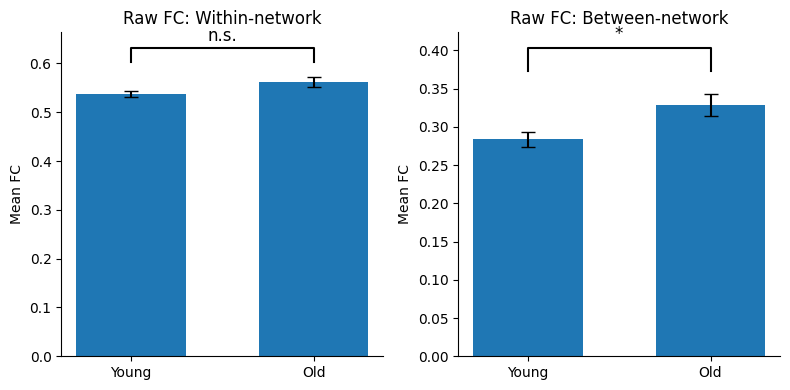

In [ ]:
# ============================================================
# Plot group means with significance annotation
# ============================================================

from scipy.stats import ttest_ind

def plot_ttest_bar(df, value_col, title, ax):
    """
    Plot the mean ± SEM for younger and older adults,
    together with the Welch's t-test result.
    """

    # --------------------------------------------------------
    # Split the data into the two age groups
    # --------------------------------------------------------
    young = df.loc[df["age_group"] == "Young", value_col].dropna()
    old = df.loc[df["age_group"] == "Old", value_col].dropna()

    # --------------------------------------------------------
    # Calculate mean and SEM for each group
    # --------------------------------------------------------
    means = [young.mean(), old.mean()]

    sems = [
        young.std(ddof=1) / np.sqrt(len(young)),
        old.std(ddof=1) / np.sqrt(len(old))
    ]

    # --------------------------------------------------------
    # Perform Welch's t-test
    # --------------------------------------------------------
    result = ttest_ind(young, old, equal_var=False)

    # --------------------------------------------------------
    # Draw the bar plot
    # --------------------------------------------------------
    ax.bar(
        ["Young", "Old"],
        means,
        yerr=sems,
        capsize=5,
        width=0.6
    )

    ax.set_ylabel("Mean FC")
    ax.set_title(title)

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --------------------------------------------------------
    # Add significance line and label
    # --------------------------------------------------------
    # Position the line slightly above the tallest error bar
    y = max(np.array(means) + np.array(sems))
    h = 0.03
    ax.plot([0, 0, 1, 1], [y+h, y+2*h, y+2*h, y+h], color="black")

    # Decide what text to display
    if result.pvalue < 0.001:
        label = "***"
    elif result.pvalue < 0.01:
        label = "**"
    elif result.pvalue < 0.05:
        label = "*"
    else:
        label = "n.s."

    ax.text(
        0.5,
        y + 2.2*h,
        label,
        ha="center",
        va="bottom",
        fontsize=12
    )


# ============================================================
# Create the figure
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

plot_ttest_bar(
    summary_df,
    "raw_within_all",
    "Raw FC: Within-network",
    axes[0]
)

plot_ttest_bar(
    summary_df,
    "raw_between_all",
    "Raw FC: Between-network",
    axes[1]
)

plt.tight_layout()
plt.show()

## Multiple Comparisons

So far, we have tested only **two** FC measures:

- overall within-network FC
- overall between-network FC

That already gives us two statistical tests. If we later test many more measures, the number of tests can grow very quickly. For example, we might test:

- 2 summary FC measures
- 20+ network-to-network comparisons
- or even 4,950 individual FC edges in a full connectome

This creates the **multiple comparison problem**.

---

**Why is this a problem?**

When we test many things at once, some results will look significant **just by chance**.

To understand this, it helps to remember two kinds of errors:

**Type I error**

A **Type I error** happens when we say there is a real effect, but in fact there is **no real effect**.  
This is a **false positive**.

Example: we test 20 brain connections, and 1 of them looks significant only because of random noise.

**Type II error**

A **Type II error** happens when there really is an effect, but our test fails to detect it.  
This is a **false negative**.

Example: a real brain difference exists, but the test is too strict and misses it.

**How this connects to multiple comparisons**

If we test many FC edges without correction, the chance of getting at least one false positive increases. That means Type I errors become more likely.

So we need to correct for multiple comparisons.

---

**Common correction methods**

There are several ways to do this:

- **Bonferroni correction**  
  A very strict method that controls the chance of making **any false positive (Type I error)** across all statistical tests. It does this by multiplying each p-value by the number of comparisons (or equivalently, dividing the significance threshold by the number of comparisons). Because it is quite strict, it greatly reduces false positives but also increases the chance of missing real effects (Type II errors). For this reason, Bonferroni is considered a **conservative** correction method.

- **False Discovery Rate (FDR)**  
  Less strict than Bonferroni. It allows a small proportion of false positives among the results that survive correction.  
  This is often called a more **liberal** method.

---

**Conservative vs liberal**

A **conservative** method is stricter. It is useful when false positives would be especially bad, such as in confirmatory analyses.

A **liberal** method is less strict. It is useful when we are exploring many possible brain connections and do not want to miss too many real effects.

---

For now, we only have **two tests**. That is a small number, so Bonferroni correction is easy to apply and easy to understand. Later, when we test many network pairs or individual edges, other more liberal correction methods may become more useful. 

In [34]:
# ============================================================
# Bonferroni correction for the two raw FC comparisons
# ============================================================

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# 1) Run Welch's t-tests for the two raw FC summary measures
# ------------------------------------------------------------
test_results = []

for col in ["raw_within_all", "raw_between_all"]:
    young = summary_df.loc[summary_df["age_group"] == "Young", col].dropna()
    old = summary_df.loc[summary_df["age_group"] == "Old", col].dropna()

    test = ttest_ind(young, old, equal_var=False)

    test_results.append({
        "measure": col,
        "young_mean": young.mean(),
        "old_mean": old.mean(),
        "t": test.statistic,
        "df": test.df,
        "p_raw": test.pvalue
    })

results_df = pd.DataFrame(test_results)

# ------------------------------------------------------------
# 2) Apply Bonferroni correction
#    Since we have 2 tests, Bonferroni multiplies each p-value by 2
# ------------------------------------------------------------
reject, p_bonf, _, _ = multipletests(results_df["p_raw"], alpha=0.05, method="bonferroni")

results_df["p_bonf"] = p_bonf
results_df["significant_after_bonf"] = reject

# ------------------------------------------------------------
# 3) Print the results clearly
# ------------------------------------------------------------
for _, row in results_df.iterrows():
    print(f"\n==================== {row['measure']} ====================")
    print(f"Young mean = {row['young_mean']:.4f}")
    print(f"Old mean   = {row['old_mean']:.4f}")
    print(f"t = {row['t']:.3f}")
    print(f"d.f. = {row['df']:.2f}")
    print(f"raw p = {row['p_raw']:.5f}")
    print(f"Bonferroni p = {row['p_bonf']:.5f}")
    print(f"Significant after Bonferroni? {row['significant_after_bonf']}")


==================== raw_within_all ====================
Young mean = 0.5380
Old mean   = 0.5616
t = -1.945
d.f. = 117.42
raw p = 0.05420
Bonferroni p = 0.10840
Significant after Bonferroni? False

==================== raw_between_all ====================
Young mean = 0.2837
Old mean   = 0.3285
t = -2.518
d.f. = 125.35
raw p = 0.01305
Bonferroni p = 0.02611
Significant after Bonferroni? True


### Interpreting the Bonferroni Correction

Bonferroni correction adjusts for multiple comparisons by making the p-values more stringent.

In our example, we performed **two statistical tests**:

1. Overall within-network FC
2. Overall between-network FC

Therefore, each p-value is multiplied by **2**:

$$
p_{\mathrm{corrected}} = p_{\mathrm{raw}} \times 2
$$

For example:

- Raw p-value = **0.013**
- Bonferroni-corrected p-value = **0.013 × 2 = 0.026**

The corrected p-value is then compared with the usual significance threshold of **0.05**.

Because the p-values become larger after correction, it becomes more difficult for a result to remain statistically significant. This reduces the chance of reporting **false positives**, but also increases the chance of missing genuine effects.

With only two comparisons, the correction is relatively small. However, imagine testing **20 network pairs** or **4,950 FC edges**. The corrected p-values would become much larger, making Bonferroni extremely conservative. This is one reason why neuroimaging studies often use other methods when testing thousands of brain connections.

When reporting, we can use the word p{sub}`adjusted`:

> There was no significant difference in overall within-network functional connectivity between younger and older adults (Welch's t(117.42) = 1.95, p{sub}`adjusted` = 0.108). In contrast, older adults showed significantly higher overall between-network functional connectivity than younger adults (Welch's t(125.35) = 2.52, p{sub}`adjusted` = 0.026).

## Bootstrapping and Confidence Intervals

Sometimes we want to estimate uncertainty without making strong assumptions about the shape of the data. This is especially useful when the distribution is not perfectly normal.

**Bootstrapping** is a resampling method. 

Imagine you have a single bag of marbles, but you want to know how the rest of the world's marbles look without buying more.

1. Sample with replacement: You blindly pick a marble, write down its color, and put it back in the bag. Because you put it back, it could be picked again.
2. Create a fake dataset: You do this until you have a new bag of the exact same size as your original one.
3. Calculate: You calculate the average (or any statistic) of this new bag.
4. Repeat: A computer repeats this process thousands of times, generating a range of averages that show how much your results naturally vary.

Now imagine you have two bags of marbles: one bag represents the younger adults and the other represents the older adults. Each marble corresponds to one participant's FC value. We repeatedly create a new version of each bag by sampling marbles with replacement (steps 1 and 2), calculate the difference in the average FC between the two bags, and repeat this thousands of times. This produces a range of plausible mean differences, allowing us to estimate how much our observed group difference could vary due to sampling alone.

> In bootstrapping, we repeatedly resample from our data, with replacement, and recalculate the statistic of interest (e.g., difference in the within network FC) each time.

A **confidence interval (CI)** is a range of values that likely contains the true answer you are looking for, built to account for the uncertainty in your data. It turns a single, strict "guess" into a realistic range, usually accompanied by a percentage like 95% confident. In our case, we are looking at the **difference in mean FC between younger and older adults**.

For example, suppose the estimated **difference** is 0.045 and the 95% CI is [0.012, 0.079]. This means there is 95% certainty that the true population effect (in this case, mean FC difference) lies somewhere between 0.012 and 0.079 contain. Therefore, since the interval does NOT include 0, a difference of no effect is **not** very plausible.

In short:

- **Bootstrapping** gives us a resampling-based way to estimate uncertainty.
- A **95% CI** gives us a plausible range for the true difference.
- If the CI does **not** include 0, that supports a real difference between the groups.

For our code, we will use bootstrapping to estimate the uncertainty around the **mean difference** in overall within or between network FC between younger and older adults.

For each bootstrap iteration:

1. Randomly sample participants from the younger group **with replacement**.
2. Randomly sample participants from the older group **with replacement**.
3. Calculate the mean FC difference between the two resampled groups.
4. Repeat this many times.

At the end, we will have a distribution of possible mean differences and can compute a **bootstrap confidence interval**.

In [ ]:
# ============================================================
# Bootstrapping the mean difference in raw between-network FC
# Using SciPy
# ============================================================

from scipy.stats import bootstrap

# ------------------------------------------------------------
# Select the data
# ------------------------------------------------------------
young = summary_df.loc[
    summary_df["age_group"] == "Young",
    "raw_between_all"
].dropna().to_numpy()

old = summary_df.loc[
    summary_df["age_group"] == "Old",
    "raw_between_all"
].dropna().to_numpy()

# Observed difference in the original sample
observed_difference = old.mean() - young.mean()

print(f"Observed mean difference (Old - Young) = {observed_difference:.4f}")

# ------------------------------------------------------------
# Define the statistic we want to bootstrap
# ------------------------------------------------------------
# We want: mean(Old) - mean(Young)
def mean_difference(x, y):
    return np.mean(y) - np.mean(x)

# ------------------------------------------------------------
# Bootstrap
# ------------------------------------------------------------
# n_resamples=5000 means we create 5000 bootstrap samples
# method="BCa" - a method in determining confidence intervals
# random_state=42 makes the result reproducible
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html 
bootstrap_result = bootstrap(
    data=(young, old),
    statistic=mean_difference,
    n_resamples=5000,
    confidence_level=0.95,
    method="BCa",
    vectorized=False,
    paired=False,
    random_state=42
)

# ------------------------------------------------------------
# Extract and print the confidence interval
# ------------------------------------------------------------
ci_low = bootstrap_result.confidence_interval.low
ci_high = bootstrap_result.confidence_interval.high

print(f"95% bootstrap confidence interval = [{ci_low:.4f}, {ci_high:.4f}]")

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------
if ci_low > 0 or ci_high < 0:
    print("Interpretation: the confidence interval does not include 0. This provides evidence that the two groups differ.")
else:
    print("Interpretation: the confidence interval includes 0. The observed difference could plausibly be zero.")

Observed mean difference (Old - Young) = 0.0448
95% bootstrap confidence interval = [0.0108, 0.0801]
Interpretation: the confidence interval does not include 0, so the difference is likely real.


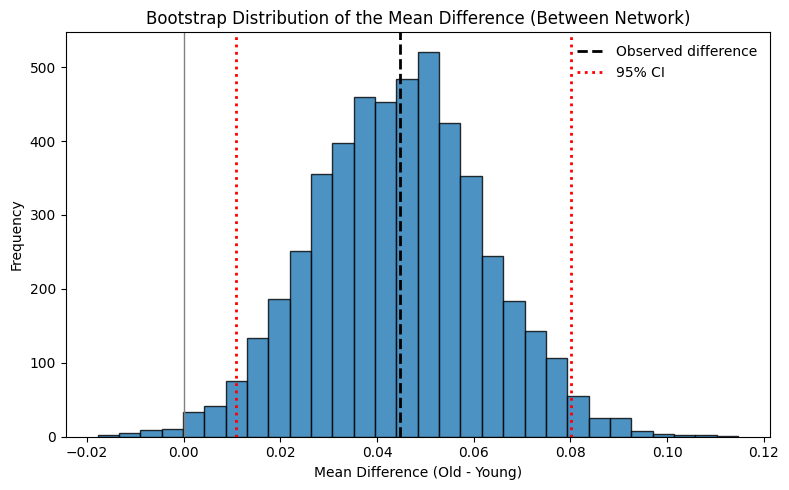

In [41]:
# ============================================================
# Visualize the bootstrap distribution
# ============================================================

# Create the figure
plt.figure(figsize=(8, 5))

# Histogram of all bootstrap estimates
plt.hist(
    bootstrap_result.bootstrap_distribution,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

# Observed mean difference
plt.axvline(
    observed_difference,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Observed difference"
)

# 95% confidence interval
plt.axvline(
    ci_low,
    color="red",
    linestyle=":",
    linewidth=2,
    label="95% CI"
)

plt.axvline(
    ci_high,
    color="red",
    linestyle=":",
    linewidth=2
)

# Reference line for no difference
plt.axvline(
    0,
    color="gray",
    linewidth=1
)

# Labels
plt.title("Bootstrap Distribution of the Mean Difference (Between Network)")
plt.xlabel("Mean Difference (Old - Young)")
plt.ylabel("Frequency")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Interpreting the Bootstrap Distribution

Each value in the bootstrap distribution is the mean difference calculated from one of the **5,000 bootstrap samples**. The histogram groups these values into bins, so taller bars indicate that many bootstrap samples produced a similar mean difference.

Notice that most bootstrap estimates cluster around the observed mean difference (black dashed line). This tells us that our estimate is fairly stable across repeated resamples.

The red dotted lines show the **95% confidence interval**. They mark the range of plausible values for the true population difference.

Finally, the gray vertical line marks **0**, which represents no difference between younger and older adults.

- If the confidence interval **does not cross 0**, the data support a real difference between the groups.
- If the confidence interval **includes 0**, then no difference remains a plausible explanation.

> Older adults showed significantly higher overall between-network functional connectivity than younger adults (Old: 0.329 ± 0.123, n = 68; Young: 0.284 ± 0.119, n = 151; Welch's t(125.35) = -2.52, Bonferroni-adjusted p = 0.026; Cohen's d = 0.373; bootstrap 95% CI [0.0108, 0.0801]).

## Permutation Testing

So far, we have used a **Welch's t-test** to determine whether the difference between the two age groups is statistically significant. However, Welch's t-test makes assumptions about the data, such as independent observations and approximately normal sampling distributions.

A **permutation test** is an alternative that makes fewer assumptions. This can be particularly useful when these assumptions are violated, for example when analysing some graph theoretical measures.

The key idea is simple:

> If there is truly **no difference** between younger and older adults, then the group labels ("Young" and "Old") should not matter.

Imagine you have two classrooms of students:

- Classroom A represents the **younger adults**.
- Classroom B represents the **older adults**.

Suppose Classroom B has a much higher average test score than Classroom A. We now ask:

> Could this difference simply be due to chance?

To answer this, we ignore the classroom labels and mix **all students together** into one large group.

1. Randomly assign the students back into two classrooms with the same number of students as before.
2. Calculate the difference in the average test score between the two new classrooms.
3. Repeat this thousands of times.

Now imagine that instead of test scores, each student has an FC value. Rather than comparing average test scores, we compare the **difference in mean FC** between younger and older adults. By repeatedly shuffling the age-group labels and recalculating the mean difference, we build a **null distribution** showing the differences we would expect if age had no effect on FC.

Finally, we compare our observed difference with this null distribution. The proportion of shuffled datasets that produce a difference at least as extreme as the observed difference is the **permutation p-value**. To make sense of this, a visualization would be helpful, which we'll do them below.

Like bootstrapping, permutation testing relies on repeated random sampling. However, instead of estimating a confidence interval, permutation testing estimates a **p-value**.

In [42]:
# ============================================================
# Permutation test using SciPy
# ============================================================

from scipy.stats import permutation_test
import numpy as np

# ------------------------------------------------------------
# Select the data
# ------------------------------------------------------------

young = summary_df.loc[
    summary_df["age_group"] == "Young",
    "raw_between_all"
].dropna().to_numpy()

old = summary_df.loc[
    summary_df["age_group"] == "Old",
    "raw_between_all"
].dropna().to_numpy()

# Observed mean difference
observed_difference = old.mean() - young.mean()

print(f"Observed mean difference (Old - Young) = {observed_difference:.4f}")

# ------------------------------------------------------------
# Statistic to compare
# ------------------------------------------------------------

def mean_difference(x, y):
    """Return the difference in means (Old - Young)."""
    return np.mean(y) - np.mean(x)

# ------------------------------------------------------------
# Run the permutation test
# ------------------------------------------------------------

permutation_result = permutation_test(
    data=(young, old),
    statistic=mean_difference,
    permutation_type="independent",
    alternative="two-sided",
    n_resamples=5000,
    random_state=42
)

print(f"Permutation p-value = {permutation_result.pvalue:.4f}")

Observed mean difference (Old - Young) = 0.0448
Permutation p-value = 0.0144


### Visualizing the Permutation Test

A good way to understand permutation testing is to plot the **null distribution**.

This null distribution is created by repeatedly shuffling the group labels ("Young" and "Old") and recalculating the mean difference each time. It shows the differences we would expect **if there were actually no real age effect**.

We then compare our **observed difference** to this shuffled distribution:

- if the observed difference falls in the extreme tail, it is unlikely to have happened by chance
- if it falls near the center, it is not unusual under the null hypothesis

In other words, the permutation plot helps us see how surprising our observed result is.

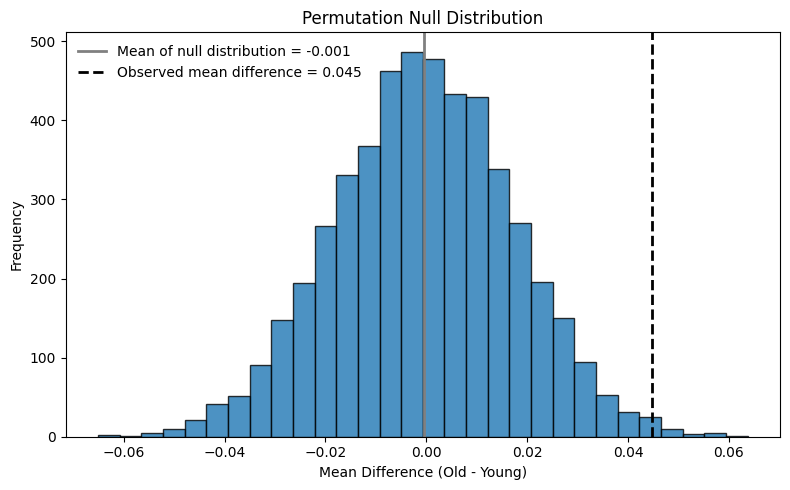

In [46]:
# Mean of the null distribution
null_mean = np.mean(null_distribution)

# ------------------------------------------------------------
# Plot the null distribution
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    null_distribution,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

# Mean of the null distribution
ax.axvline(
    null_mean,
    color="gray",
    linestyle="-",
    linewidth=2,
    label=f"Mean of null distribution = {null_mean:.3f}"
)

# Observed mean difference
ax.axvline(
    observed_difference,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Observed mean difference = {observed_difference:.3f}"
)

ax.set_title("Permutation Null Distribution")
ax.set_xlabel("Mean Difference (Old - Young)")
ax.set_ylabel("Frequency")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### Interpreting the Permutation Test

The permutation test creates **5,000 shuffled versions** of the original dataset under the assumption that there is **no true difference** between the age groups.

If only a small proportion of these shuffled datasets produce a difference as large as the one we observed, the permutation p-value will be small.

For example:

- **p < 0.05** suggests that the observed difference is unlikely to have occurred by chance alone.
- **p ≥ 0.05** suggests that the observed difference could reasonably occur simply due to random variation.

Unlike bootstrapping, which estimates a confidence interval, permutation testing directly tests the null hypothesis that the two groups do not differ.

# Part 3: Thinking Like a Neuroscientist and Possible Next Steps

Before running more code, we should step back and ask what the literature already says. The goal is not to search for every possible paper, but to place our own research question in context and identify what is already known, what is still debated, and what is still missing. 

You might find that in aging research, many studies describe a general shift toward a more integrated and less segregated resting-state network organization, often summarized as lower within-network connectivity and higher between-network connectivity with age. However, this pattern is not identical across all networks or all datasets, and some work suggests that specific systems such as the default mode and executive-control/frontoparietal networks are especially affected.

That is why a good first literature exercise is to ask a focused question such as: “In healthy aging, does resting-state connectivity usually go up or down within networks? What about between networks? Which networks are most often reported to change?” 

If you read a few review papers and a few primary studies, you will quickly see that the answer is not a simple yes/no story. Aging affects more than resting-state connectivity alone, and even within rsFC the result can depend on the network, the connectivity metric, the sample, and the analysis choices. 

As a scientist, it's important we narrow our scope. Since we are focusing on resting-state networks and age only, a sensible workflow could be:

1. Start with the broad question: do younger and older adults differ in overall within-network FC and overall between-network FC? (Completed)
2. Then move to a more specific question: are any of the seven within-network averages different between groups? Remember to utilize `get_network_pair_fc` function. 
3. Use multiple-comparison correction, because once you test many networks or network pairs, some “significant” results will appear by chance.

This last step matters. If you test only two summary measures, the correction burden is small. If you test 7 within-network values, that becomes 7 comparisons. If you test all pairwise network combinations, that becomes 21 comparisons. That is exactly why we should not compare “everything under the sun” when we already have a specific hypothesis. 

We hope this has given you some research ideas to think about. With comparison statistics, you can compare across different groups. Groups could be anything, from sex to handedness to dividing populations with high vs low scores on specific cognitive, emotion-related, or personality questionnaires. 